# Reto de Limpieza de Datos: Ventas Colombia 2024

**Ejecutor:** Víctor Aguilar
**Mentor:** Jose
**Bootcamp AVD · Talento Tech 2026**

### Pregunta problema
¿Cuáles son los productos más rentables por ciudad y canal de venta en
Colombia durante 2024, y qué vendedor tiene el mayor desempeño según la
satisfacción del cliente?

## Setup

| Librería | Uso |
|---|---|
| `pandas` | Carga, limpieza y agregaciones |
| `numpy` | Operaciones numéricas y máscaras |
| `matplotlib` | Visualizaciones base y formato de ejes |
| `seaborn` | Gráficos estadísticos con estilo |

El estilo global se configura una sola vez y aplica a todas las
visualizaciones del notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Versiones ---
print(f"Pandas    : {pd.__version__}")
print(f"NumPy     : {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn   : {sns.__version__}")

# --- Estilo global de gráficos ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize"  : (10, 5),
    "figure.dpi"      : 120,
    "axes.titlesize"  : 13,
    "axes.titleweight": "bold",
    "axes.labelsize"  : 11,
    "xtick.labelsize" : 10,
    "ytick.labelsize" : 10,
})

print("\nSetup listo.")

Pandas    : 2.2.2
NumPy     : 2.0.2
Matplotlib: 3.10.0
Seaborn   : 0.13.2

Setup listo.


## Paso 1 — Carga de datos

- Fuente: `ventas_sucias.csv`, exportado desde `ventas_sucias.db` (SQLite).
- Grano: una fila = una transacción de venta. Clave primaria: `id`.
- Volumen original: **49 registros, 11 columnas**.
- Encoding `utf-8-sig`: compatibilidad con tildes y BOM de Excel.

In [ ]:
df_raw = pd.read_csv("ventas_sucias.csv", encoding="utf-8-sig")

print(f"Dimensiones : {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
print(f"\nTipos de dato:")
print(df_raw.dtypes)
print(f"\nPrimeras filas:")
df_raw.head(10)

Dimensiones : 49 filas x 11 columnas

Tipos de dato:
id                        int64
fecha                    object
vendedor                 object
ciudad                   object
categoria                object
producto                 object
cantidad                float64
precio_unitario          object
ingreso_total            object
canal_venta              object
satisfaccion_cliente    float64
dtype: object

Primeras filas:


,id,fecha,vendedor,ciudad,categoria,producto,cantidad,precio_unitario,ingreso_total,canal_venta,satisfaccion_cliente
0,1,2024-01-05,Ana Torres,Bogotá,Electrónica,Laptop,2.0,2500000,5000000,Online,4.5
1,2,2024-01-07,Carlos Ríos,Medellín,Ropa,Camiseta,10.0,45000,450000,Tienda,3.8
2,3,2024-01-10,María López,Cali,Alimentos,Café Premium,5.0,32000,160000,Online,5.0
3,4,2024-01-12,Pedro Gómez,Barranquilla,Electrónica,Audífonos,3.0,180000,540000,Tienda,4.2
4,5,2024-01-15,Ana Torres,Bogotá,Hogar,Licuadora,1.0,320000,320000,Online,4.7
5,6,2024-01-18,Carlos Ríos,Medellín,Electrónica,Tablet,2.0,1200000,2400000,Tienda,4.0
6,7,2024-01-20,Laura Díaz,Cali,Ropa,Zapatos,4.0,210000,840000,Online,3.5
7,8,2024-01-22,Pedro Gómez,Bogotá,Alimentos,Granola,8.0,28000,224000,Tienda,4.1
8,9,2024-01-25,María López,Barranquilla,Hogar,Ventilador,2.0,95000,190000,Online,3.9
9,10,2024-02-02,Laura Díaz,Medellín,Electrónica,Celular,1.0,1800000,1800000,Tienda,4.8


## Paso 2 — Auditoría inicial

Antes de limpiar, caracterizamos el dataset completo: tipos reales, nulos,
cadenas vacías y anomalías de dominio. Las decisiones del Paso 3 se derivan
directamente de esta auditoría.

In [ ]:
print("=" * 55)
print("AUDITORÍA INICIAL — DATOS CRUDOS")
print("=" * 55)

# 1. Tipos reales
print("\n1. TIPOS DE DATO:")
print(df_raw.dtypes)

# 2. Nulos reales
print("\n2. NULOS REALES (NaN):")
print(df_raw.isnull().sum())

# 3. Cadenas vacías (solo columnas object)
cols_obj = df_raw.select_dtypes(include="object").columns
print("\n3. CADENAS VACÍAS (''):")
print((df_raw[cols_obj] == "").sum())

# 4. Valores únicos — columnas categóricas con posibles inconsistencias
print("\n4. VALORES ÚNICOS POR COLUMNA CATEGÓRICA:")
for col in ["ciudad", "canal_venta", "categoria"]:
    print(f"  {col}: {sorted(df_raw[col].dropna().unique())}")

# 5. Rango de satisfacción
print("\n5. RANGO satisfaccion_cliente:")
print(df_raw["satisfaccion_cliente"].describe())
print(f"  Valores fuera de [1,5]: "
      f"{((df_raw['satisfaccion_cliente'] < 1) | (df_raw['satisfaccion_cliente'] > 5)).sum()}")

# 6. Todos los valores — precio_unitario e ingreso_total
print("\n6. TODOS LOS VALORES — precio_unitario:")
print(sorted(df_raw["precio_unitario"].dropna().unique()))

print("\n   TODOS LOS VALORES — ingreso_total:")
print(sorted(df_raw["ingreso_total"].dropna().unique()))

print("\n   Registros con NaN en precio o ingreso:")
mask_num = df_raw["precio_unitario"].isna() | df_raw["ingreso_total"].isna()
print(df_raw[mask_num][["id", "fecha", "vendedor", "producto",
                        "cantidad", "precio_unitario", "ingreso_total"]])

# 7. Todos los formatos de fecha
print("\n7. TODOS LOS VALORES — fecha:")
print(sorted(df_raw["fecha"].dropna().unique()))

# 8. Duplicados lógicos
cols_clave = ["fecha", "vendedor", "ciudad", "producto",
              "cantidad", "precio_unitario"]
print(f"\n8. DUPLICADOS LÓGICOS (subset sin id): "
      f"{df_raw.duplicated(subset=cols_clave).sum()}")

AUDITORÍA INICIAL — DATOS CRUDOS

1. TIPOS DE DATO:
id                        int64
fecha                    object
vendedor                 object
ciudad                   object
categoria                object
producto                 object
cantidad                float64
precio_unitario          object
ingreso_total            object
canal_venta              object
satisfaccion_cliente    float64
dtype: object

2. NULOS REALES (NaN):
id                      0
fecha                   0
vendedor                1
ciudad                  1
categoria               1
producto                0
cantidad                1
precio_unitario         1
ingreso_total           1
canal_venta             0
satisfaccion_cliente    1
dtype: int64

3. CADENAS VACÍAS (''):
fecha              0
vendedor           0
ciudad             0
categoria          0
producto           0
precio_unitario    0
ingreso_total      0
canal_venta        0
dtype: int64

4. VALORES ÚNICOS POR COLUMNA CATEGÓRICA:
  ciudad: 

### Resumen de auditoría — decisiones para el Paso 3

| # | Problema | Columna(s) | Decisión |
|---|---|---|---|
| 1 | 2 duplicados lógicos | subset sin `id` | `drop_duplicates` por columnas de negocio |
| 2 | 1 NaN en `vendedor` | `vendedor` | No imputar. Excluir del ranking |
| 3 | 1 NaN en `ciudad` | `ciudad` | Imputar `"Sin Ciudad"` |
| 4 | 1 NaN en `categoria` | `categoria` | Imputar `"Sin Categoría"` |
| 5 | `precio_unitario` e `ingreso_total` como object con símbolos | ambas | Limpiar `$`, puntos y comas con regex, luego `pd.to_numeric` |
| 6 | id 22: `precio_unitario` NaN, `ingreso_total` y `cantidad` disponibles | `precio_unitario` | Reconstruir: `precio = ingreso / cantidad` |
| 7 | id 21: `cantidad` NaN, `ingreso_total` NaN | fila completa | Eliminar. Irrecuperable |
| 8 | 8 variantes para 4 ciudades | `ciudad` | `.str.title()` + diccionario de tildes |
| 9 | 6 variantes para 2 canales | `canal_venta` | Diccionario de mapeo |
| 10 | 3 formatos mixtos en fecha | `fecha` | `pd.to_datetime(errors='coerce')` |
| 11 | 3 valores fuera de rango en satisfacción | `satisfaccion_cliente` | `clip(1, 5)` |

### Resultado esperado tras limpieza de duplicados y

| Métrica | Valor |
|---|---|
| Filas originales | 49 |
| Duplicados eliminados | 2 |
| **Filas limpias** | **47** |

## Paso 3 — Limpieza de datos

Trabajamos sobre una copia de `df_raw` para preservar los datos originales.
El orden del pipeline se deriva directamente de la auditoría del Paso 2.

### 3.1 — Duplicados

Criterio: dos filas son duplicado lógico si coinciden en todas las columnas
de negocio. No se usa `id` porque es autoincremental y siempre único.
Acción: conservar la primera ocurrencia.

In [ ]:
df = df_raw.copy()

cols_clave = ["fecha", "vendedor", "ciudad", "producto",
              "cantidad", "precio_unitario"]

n_antes = len(df)
df = df.drop_duplicates(subset=cols_clave, keep="first").reset_index(drop=True)

print(f"Duplicados eliminados : {n_antes - len(df)}")
print(f"Filas restantes       : {len(df)}")

Duplicados eliminados : 2
Filas restantes       : 47


### 3.2 — Limpieza y conversión de columnas numéricas

La auditoría reveló que `precio_unitario` e `ingreso_total` tienen símbolos
y separadores mixtos:

| Patrón detectado | Ejemplo |
|---|---|
| Símbolo `$` y puntos como miles | `$1.800.000` |
| Punto como miles | `120.000` |
| Coma como miles | `32,000` |
| String numérico limpio | `120000` |

Solución: función de limpieza con regex antes de `pd.to_numeric`.
Con tipos correctos se aplican las máscaras de reconstrucción y eliminación.

In [ ]:
def limpiar_numero(serie):
    return (
        serie.astype(str)
             .str.strip()
             .str.replace(r"[$]", "", regex=True)
             .str.replace(r"\.", "", regex=True)
             .str.replace(r",", "", regex=True)
             .pipe(pd.to_numeric, errors="coerce")
    )

df["precio_unitario"] = limpiar_numero(df["precio_unitario"])
df["ingreso_total"]   = limpiar_numero(df["ingreso_total"])
df["cantidad"]        = pd.to_numeric(df["cantidad"], errors="coerce")

# Reconstruir precio donde ingreso y cantidad existen
mask_precio = (df["precio_unitario"].isna() &
               df["ingreso_total"].notna() &
               df["cantidad"].notna())
df.loc[mask_precio, "precio_unitario"] = (
    df.loc[mask_precio, "ingreso_total"] / df.loc[mask_precio, "cantidad"]
)
print(f"Precios reconstruidos : {mask_precio.sum()}")

# Identificar fila irrecuperable (sin cantidad ni ingreso)
mask_irrecuperable = df["cantidad"].isna() & df["ingreso_total"].isna()

print(f"Filas irrecuperables identificadas : {mask_irrecuperable.sum()}")
if mask_irrecuperable.sum() > 0:
    print("\nRegistro(s) a eliminar:")
    print(df[mask_irrecuperable][["id","vendedor","producto",
                                   "cantidad","precio_unitario","ingreso_total"]])

# Eliminar
df = df[~mask_irrecuperable].reset_index(drop=True)
print(f"\nFilas restantes : {len(df)}")

Precios reconstruidos : 1
Filas irrecuperables identificadas : 1

Registro(s) a eliminar:
    id     vendedor    producto  cantidad  precio_unitario  ingreso_total
20  21  María López  Ventilador       NaN          95000.0            NaN

Filas restantes : 46


### 3.3 — Nulos en columnas categóricas y vendedor

`vendedor` es identidad: no se imputa. Se separa para reporte y se excluye
del ranking de desempeño. `ciudad` y `categoria` se imputan con etiqueta
descriptiva para preservar la transacción en otros análisis.

In [ ]:
# Vendedor — no imputar, separar para reporte
mask_sin_vendedor = df["vendedor"].isna()
print(f"Transacciones sin vendedor : {mask_sin_vendedor.sum()} "
      f"(excluidas del ranking)")

# Ciudad y categoría — imputar
df["ciudad"]    = df["ciudad"].fillna("Sin Ciudad")
df["categoria"] = df["categoria"].fillna("Sin Categoría")

print(f"Nulos restantes en ciudad    : {df['ciudad'].isna().sum()}")
print(f"Nulos restantes en categoria : {df['categoria'].isna().sum()}")

Transacciones sin vendedor : 1 (excluidas del ranking)
Nulos restantes en ciudad    : 0
Nulos restantes en categoria : 0


### 3.4 — Normalización de ciudad

La auditoría detectó 8 variantes para 4 ciudades: mayúsculas completas,
minúsculas y tildes faltantes. Solución en dos pasos: `.str.title()` para
capitalizar, luego diccionario para corregir tildes.

In [ ]:
df["ciudad"] = df["ciudad"].str.strip().str.title()

mapa_ciudades = {
    "Bogota"  : "Bogotá",
    "Medellin": "Medellín"
}
df["ciudad"] = df["ciudad"].replace(mapa_ciudades)

print("Ciudades únicas tras normalización:")
print(sorted(df["ciudad"].unique()))

Ciudades únicas tras normalización:
['Barranquilla', 'Bogotá', 'Cali', 'Medellín', 'Sin Ciudad']


### 3.5 — Normalización de canal de venta

La auditoría detectó 6 variantes para 2 categorías reales.
Solución: diccionario de mapeo explícito.

In [ ]:
mapa_canal = {
    "online"    : "Online",
    "e-commerce": "Online",
    "TIENDA"    : "Tienda",
    "fisica"    : "Tienda"
}
df["canal_venta"] = df["canal_venta"].replace(mapa_canal)

print("Canales únicos tras normalización:")
print(sorted(df["canal_venta"].unique()))

Canales únicos tras normalización:
['Online', 'Tienda']


### 3.6 — Fechas

La auditoría reveló 3 formatos atípicos junto al ISO dominante:

| Formato detectado | Ejemplo |
|---|---|
| DD/MM/YYYY | `05/02/2024` |
| YYYY/MM/DD | `2024/02/10` |
| Texto en inglés | `February 15 2024` |

Cada caso se mapea explícitamente a ISO antes de `pd.to_datetime`.
Esto evita perder transacciones por descarte automático con
`errors='coerce'`. Si quedaran NaT tras este paso, serían formatos
no previstos que requerirían inspección manual.

In [ ]:
# Limpieza manual de formatos atípicos ANTES de pd.to_datetime
df["fecha"] = (df["fecha"]
    .astype(str)
    .str.strip()
    .replace({
        "05/02/2024"       : "2024-02-05",
        "2024/02/10"       : "2024-02-10",
        "February 15 2024" : "2024-02-15"
    })
)

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

nat = df["fecha"].isna().sum()
print(f"Fechas no convertibles (NaT) : {nat}")
print(f"Rango de fechas              : {df['fecha'].min()} → {df['fecha'].max()}")

Fechas no convertibles (NaT) : 0
Rango de fechas              : 2024-01-05 00:00:00 → 2024-06-05 00:00:00


### 3.7 — Satisfacción del cliente

La auditoría detectó 3 valores fuera del rango válido [1, 5]: -1, 0, 8.
Decisión: `clip(1, 5)` acota al extremo válido más cercano. Preserva la
transacción para todos los análisis.

El NaN restante corresponde a id=22 (Ana Torres, Cali): transacción válida
donde el cliente simplemente no calificó. Se conserva la fila. pandas la
excluye automáticamente en cálculos de promedio (`skipna=True`).

Nota matemática: ignorar el NaN no es equivalente a asumirlo como cero.
En el primer caso el denominador se ajusta al número real de observaciones
disponibles; en el segundo se contamina el promedio con un valor que no
existe en los datos.

In [ ]:
df["satisfaccion_cliente"] = pd.to_numeric(
    df["satisfaccion_cliente"], errors="coerce"
).clip(1, 5)

print(f"Rango tras clip : {df['satisfaccion_cliente'].min()} — "
      f"{df['satisfaccion_cliente'].max()}")
print(f"NaN restantes   : {df['satisfaccion_cliente'].isna().sum()}")

Rango tras clip : 1.0 — 5.0
NaN restantes   : 1


In [ ]:
print("Registro con NaN en satisfaccion_cliente:")
df[df["satisfaccion_cliente"].isna()]

Registro con NaN en satisfaccion_cliente:


,id,fecha,vendedor,ciudad,categoria,producto,cantidad,precio_unitario,ingreso_total,canal_venta,satisfaccion_cliente
20,22,2024-03-10,Ana Torres,Cali,Ropa,Zapatos,3.0,210000.0,630000.0,Tienda,NaN


### Inspección del NaN restante

El registro id=22 (Ana Torres, Cali, Zapatos) es una transacción comercial
completamente válida: todos los datos de negocio están presentes
(fecha, vendedor, ciudad, producto, cantidad, precio, ingreso).

Lo único ausente es la calificación del cliente. No es un error de captura:
es información genuinamente ausente porque el cliente no respondió la encuesta.

**Por qué se conserva la fila:**

- Imputar sería inventar datos sin base estadística honesta.
- Eliminar perdería información válida para los demás análisis (ingresos
  por ciudad, ranking de productos, desempeño monetario de Ana Torres).
- `pandas` excluye automáticamente este NaN con `skipna=True` al calcular
  promedios, ajustando el denominador al número real de observaciones.

Regla general: la ausencia de un atributo opcional no invalida la transacción.

## Paso 4 — Validación final

Verificamos que el pipeline produjo un dataset coherente: tipos correctos,
rangos válidos, categorías consolidadas y conteo de filas alineado con lo
esperado.

In [ ]:
print("=" * 55)
print("REPORTE DE CALIDAD — DATOS LIMPIOS")
print("=" * 55)

print(f"\nFilas originales  : 49")
print(f"Duplicados        : -2")
print(f"Irrecuperables    : -1")
print(f"Filas limpias     : {len(df)}")

print(f"\nTipos de dato:")
print(df.dtypes)

print(f"\nNulos restantes:")
print(df.isnull().sum())

print(f"\nCiudades  : {sorted(df['ciudad'].unique())}")
print(f"Canales   : {sorted(df['canal_venta'].unique())}")

print(f"\nRango fecha        : {df['fecha'].min()} → {df['fecha'].max()}")
print(f"Rango satisfacción : {df['satisfaccion_cliente'].min()} — "
      f"{df['satisfaccion_cliente'].max()}")
print(f"Rango precio       : {df['precio_unitario'].min():,.0f} — "
      f"{df['precio_unitario'].max():,.0f}")

REPORTE DE CALIDAD — DATOS LIMPIOS

Filas originales  : 49
Duplicados        : -2
Irrecuperables    : -1
Filas limpias     : 46

Tipos de dato:
id                               int64
fecha                   datetime64[ns]
vendedor                        object
ciudad                          object
categoria                       object
producto                        object
cantidad                       float64
precio_unitario                float64
ingreso_total                  float64
canal_venta                     object
satisfaccion_cliente           float64
dtype: object

Nulos restantes:
id                      0
fecha                   0
vendedor                1
ciudad                  0
categoria               0
producto                0
cantidad                0
precio_unitario         0
ingreso_total           0
canal_venta             0
satisfaccion_cliente    1
dtype: int64

Ciudades  : ['Barranquilla', 'Bogotá', 'Cali', 'Medellín', 'Sin Ciudad']
Canales   : ['Online',

## Paso 5 — Análisis exploratorio (EDA)

Con el dataset limpio respondemos la pregunta problema:

> ¿Cuáles son los productos más rentables por ciudad y canal de venta en
> Colombia durante 2024, y qué vendedor tiene el mayor desempeño según la
> satisfacción del cliente?

El análisis se organiza en cuatro bloques:

| Bloque | Pregunta que responde |
|---|---|
| 5.1 KPIs generales | ¿Cuál es el panorama global del negocio? |
| 5.2 Por ciudad | ¿Dónde se concentran los ingresos? |
| 5.3 Por canal y producto | ¿Qué se vende mejor y por dónde? |
| 5.4 Ranking de vendedores | ¿Quién tiene mejor desempeño combinado? |

### 5.1 — KPIs generales

Cuatro métricas básicas que dan el panorama global del negocio:

| KPI | Definición |
|---|---|
| Ingreso total | Suma de `ingreso_total` |
| Transacciones | Conteo de filas |
| Ticket promedio | Media de `ingreso_total` |
| Satisfacción promedio | Media de `satisfaccion_cliente` con `skipna=True` |

In [ ]:
total         = df["ingreso_total"].sum()
transacciones = len(df)
ticket        = df["ingreso_total"].mean()
satisfaccion  = df["satisfaccion_cliente"].mean(skipna=True)

print("=" * 50)
print("KPIs GENERALES")
print("=" * 50)
print(f"  Ingreso total      : ${total:>15,.0f} COP")
print(f"  Transacciones      : {transacciones:>15}")
print(f"  Ticket promedio    : ${ticket:>15,.0f} COP")
print(f"  Satisfacción media : {satisfaccion:>15.2f} / 5.0")
print("=" * 50)

KPIs GENERALES
  Ingreso total      : $     57,747,000 COP
  Transacciones      :              46
  Ticket promedio    : $      1,255,370 COP
  Satisfacción media :            4.15 / 5.0


### 5.2 — Ingresos por ciudad

¿Dónde se concentran los ingresos? Agrupamos por ciudad y ordenamos
de mayor a menor. Esta segmentación identifica el mercado dominante
y posibles oportunidades de expansión en mercados secundarios.

In [ ]:
ingresos_ciudad = (df.groupby("ciudad")["ingreso_total"]
                     .agg(["sum", "count", "mean"])
                     .rename(columns={"sum"  : "ingreso_total",
                                       "count": "transacciones",
                                       "mean" : "ticket_promedio"})
                     .sort_values("ingreso_total", ascending=False))

ingresos_ciudad["%_del_total"] = (
    ingresos_ciudad["ingreso_total"] / total * 100
).round(1)

print("INGRESOS POR CIUDAD")
print("=" * 60)
print(ingresos_ciudad.to_string(
    formatters={
        "ingreso_total"  : "${:,.0f}".format,
        "ticket_promedio": "${:,.0f}".format,
        "%_del_total"    : "{:.1f}%".format
    }
))

INGRESOS POR CIUDAD
             ingreso_total  transacciones ticket_promedio %_del_total
ciudad                                                               
Bogotá         $33,074,000             15      $2,204,933       57.3%
Medellín        $8,898,000             11        $808,909       15.4%
Cali            $8,677,000             11        $788,818       15.0%
Barranquilla    $7,014,000              8        $876,750       12.1%
Sin Ciudad         $84,000              1         $84,000        0.1%


### Paleta y helpers de visualización

Para mantener coherencia visual con el HTML del proyecto, se define una
paleta inspirada en Catppuccin (estándar usado en el inspector original)
y un helper para formato monetario.

| Color | Hex | Uso |
|---|---|---|
| Azul principal | `#89b4fa` | Barras y series primarias |
| Gris secundario | `#a6adc8` | Series comparativas o de fondo |
| Rosa acento | `#f38ba8` | Resaltar valores destacados |
| Texto | `#1e1e2e` | Etiquetas y títulos |

In [ ]:
# Paleta del proyecto (alineada al HTML)
PALETA = {
    "primario"   : "#89b4fa",
    "secundario" : "#a6adc8",
    "acento"     : "#f38ba8",
    "texto"      : "#1e1e2e"
}

# Helper de formato monetario para ejes
def fmt_cop(x, pos):
    if x >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"${x/1_000:.0f}K"
    return f"${x:.0f}"

formato_cop = mticker.FuncFormatter(fmt_cop)
print("Paleta y helpers cargados.")

Paleta y helpers cargados.


### Visualización 5.2

Gráfico de barras horizontal: ranking visual de ingresos por ciudad
con porcentaje sobre cada barra. Bogotá se resalta como ciudad
dominante con color de acento.

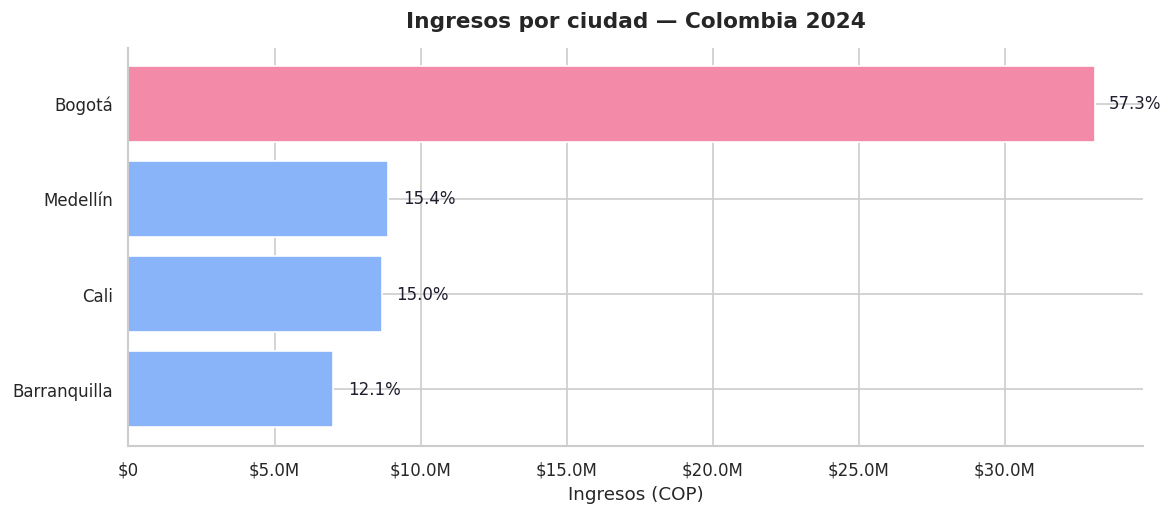

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))

# Datos (excluir "Sin Ciudad" del visual por su peso marginal)
data_plot = ingresos_ciudad[ingresos_ciudad.index != "Sin Ciudad"].iloc[::-1]

# Color especial para la ciudad líder
colores = [PALETA["acento"] if c == "Bogotá" else PALETA["primario"]
           for c in data_plot.index]

barras = ax.barh(data_plot.index, data_plot["ingreso_total"], color=colores)

# Etiquetas con porcentaje al final de cada barra
for i, (ciudad, fila) in enumerate(data_plot.iterrows()):
    ax.text(fila["ingreso_total"] + 500_000, i,
            f'{fila["%_del_total"]:.1f}%',
            va="center", fontsize=10, color=PALETA["texto"])

ax.set_title("Ingresos por ciudad — Colombia 2024", pad=12)
ax.set_xlabel("Ingresos (COP)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(formato_cop)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### 5.3 — Ingresos por canal de venta y productos líderes

Dos preguntas en una vista:

1. ¿Qué canal mueve más ingresos, Online o Tienda?
2. ¿Qué productos lideran el negocio?

El cruce de ambos análisis revela si la estrategia comercial
debe diferenciarse por canal.

In [ ]:
# --- Ingresos por canal ---
ingresos_canal = (df.groupby("canal_venta")["ingreso_total"]
                    .agg(["sum", "count"])
                    .rename(columns={"sum": "ingreso_total",
                                      "count": "transacciones"})
                    .sort_values("ingreso_total", ascending=False))

ingresos_canal["%_del_total"] = (
    ingresos_canal["ingreso_total"] / total * 100
).round(1)

print("INGRESOS POR CANAL DE VENTA")
print("=" * 55)
print(ingresos_canal.to_string(
    formatters={
        "ingreso_total": "${:,.0f}".format,
        "%_del_total"  : "{:.1f}%".format
    }
))

# --- Top productos ---
top_productos = (df.groupby("producto")["ingreso_total"]
                   .sum()
                   .sort_values(ascending=False)
                   .head(5))

print("\n\nTOP 5 PRODUCTOS POR INGRESO")
print("=" * 55)
for i, (prod, valor) in enumerate(top_productos.items(), 1):
    pct = valor / total * 100
    print(f"  {i}. {prod:<15} ${valor:>12,.0f}  ({pct:.1f}%)")

INGRESOS POR CANAL DE VENTA
            ingreso_total  transacciones %_del_total
canal_venta                                         
Online        $40,455,000             25       70.1%
Tienda        $17,292,000             21       29.9%


TOP 5 PRODUCTOS POR INGRESO
  1. Laptop          $  22,500,000  (39.0%)
  2. Celular         $  12,600,000  (21.8%)
  3. Tablet          $   7,200,000  (12.5%)
  4. Audífonos       $   3,420,000  (5.9%)
  5. Licuadora       $   3,200,000  (5.5%)


### Visualización 5.3

Dos subplots horizontales:

- Izquierda: barra apilada que muestra la proporción Online vs Tienda
  en una sola línea visual (formato del HTML original).
- Derecha: top 5 productos por ingreso, con el líder resaltado en color acento.

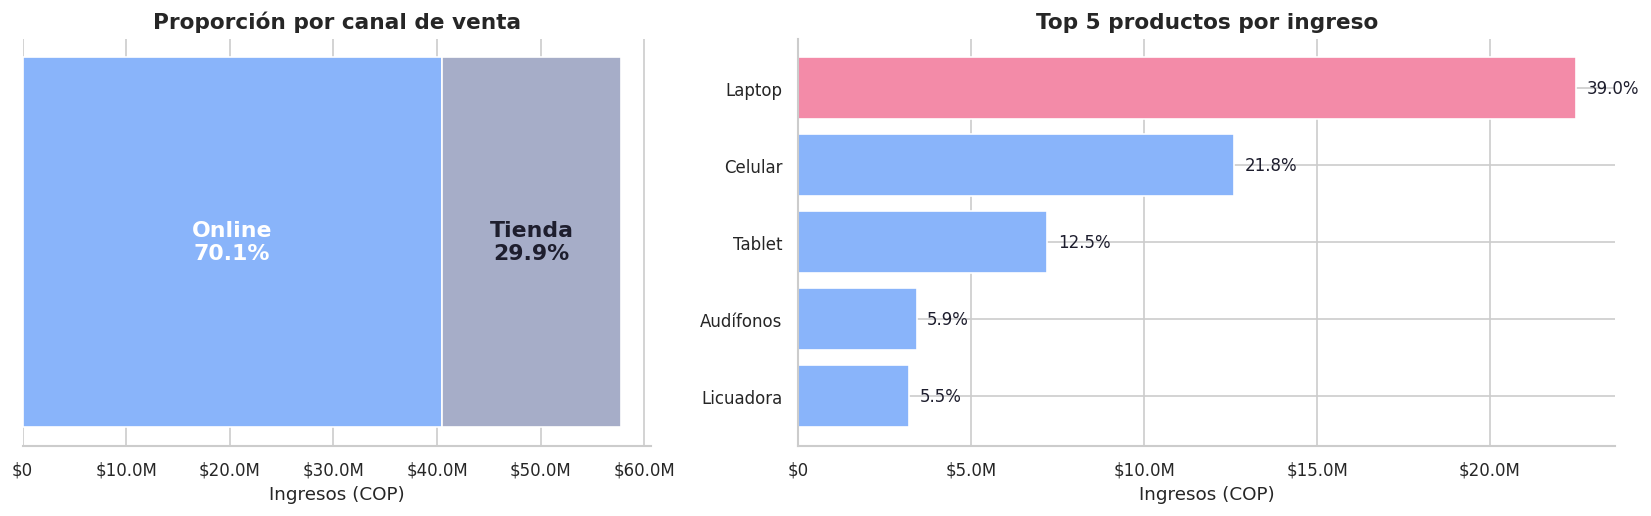

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5),
                          gridspec_kw={"width_ratios": [1, 1.3]})

# --- Izquierda: Canal de venta (barra apilada horizontal) ---
ax1 = axes[0]
online  = ingresos_canal.loc["Online", "ingreso_total"]
tienda  = ingresos_canal.loc["Tienda", "ingreso_total"]
pct_on  = ingresos_canal.loc["Online", "%_del_total"]
pct_ti  = ingresos_canal.loc["Tienda", "%_del_total"]

ax1.barh([0], [online], color=PALETA["primario"],   label=f"Online ({pct_on:.1f}%)")
ax1.barh([0], [tienda], left=[online],
         color=PALETA["secundario"], label=f"Tienda ({pct_ti:.1f}%)")

# Etiquetas dentro de cada segmento
ax1.text(online/2, 0, f"Online\n{pct_on:.1f}%",
         ha="center", va="center", color="white", fontweight="bold")
ax1.text(online + tienda/2, 0, f"Tienda\n{pct_ti:.1f}%",
         ha="center", va="center", color=PALETA["texto"], fontweight="bold")

ax1.set_yticks([])
ax1.set_title("Proporción por canal de venta")
ax1.set_xlabel("Ingresos (COP)")
ax1.xaxis.set_major_formatter(formato_cop)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_visible(False)

# --- Derecha: Top productos ---
ax2 = axes[1]
prods_plot = top_productos.iloc[::-1]
colores_p = [PALETA["acento"] if i == len(prods_plot)-1 else PALETA["primario"]
             for i in range(len(prods_plot))]

ax2.barh(prods_plot.index, prods_plot.values, color=colores_p)

for i, (prod, valor) in enumerate(prods_plot.items()):
    pct = valor / total * 100
    ax2.text(valor + 300_000, i, f"{pct:.1f}%",
             va="center", fontsize=10, color=PALETA["texto"])

ax2.set_title("Top 5 productos por ingreso")
ax2.set_xlabel("Ingresos (COP)")
ax2.xaxis.set_major_formatter(formato_cop)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### 5.4 — Ranking de vendedores

El HTML original definió un **score compuesto** que combina dos dimensiones:

$$
\text{score} = \frac{\text{ingreso}_{\text{vendedor}}}{\max(\text{ingreso})} \times \frac{\overline{\text{satisfaccion}}}{5}
$$

**Por qué un score compuesto:**

Un vendedor con alta satisfacción pero pocas ventas no es el mejor.
Un vendedor con muchas ventas pero baja satisfacción tampoco.
El score multiplicativo penaliza los desbalances: solo destaca quien
combina ambas dimensiones.

**Exclusiones:**
- Registros sin vendedor (1 fila): no entran al ranking.
- NaN en satisfacción (id=22, Ana Torres): `skipna=True` lo excluye del promedio.

### Visualización 5.4

Tres subplots horizontales que descomponen el ranking:

1. Score compuesto: ranking final.
2. Ingreso total: dimensión monetaria.
3. Satisfacción promedio: dimensión cualitativa.

Ana Torres se resalta en color acento por liderar ambas dimensiones.

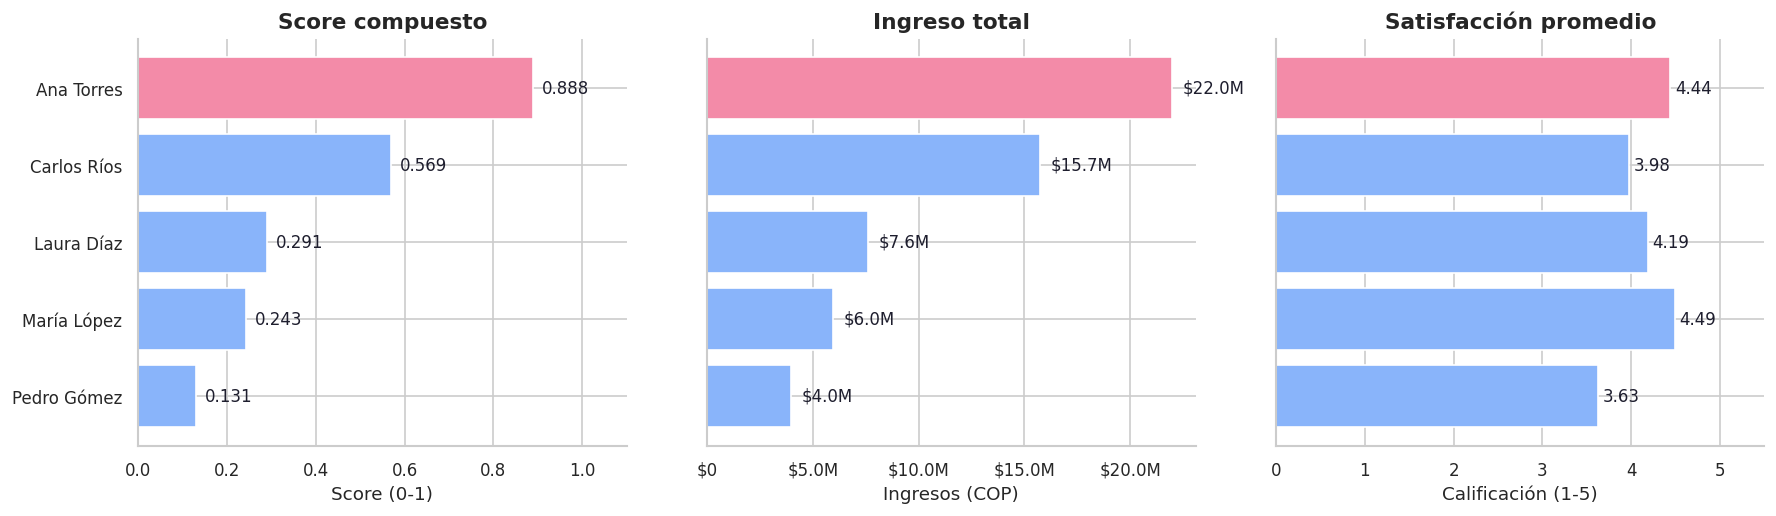

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

vendedores = ranking.index[::-1]  # invertir para que el líder quede arriba

colores_v = [PALETA["acento"] if v == "Ana Torres" else PALETA["primario"]
             for v in vendedores]

# --- 1. Score compuesto ---
ax1 = axes[0]
ax1.barh(vendedores, ranking["score"].iloc[::-1], color=colores_v)
for i, v in enumerate(vendedores):
    ax1.text(ranking.loc[v, "score"] + 0.02, i,
             f'{ranking.loc[v, "score"]:.3f}',
             va="center", fontsize=10, color=PALETA["texto"])
ax1.set_title("Score compuesto")
ax1.set_xlabel("Score (0-1)")
ax1.set_xlim(0, 1.1)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# --- 2. Ingreso total ---
ax2 = axes[1]
ax2.barh(vendedores, ranking["ingreso"].iloc[::-1], color=colores_v)
for i, v in enumerate(vendedores):
    val = ranking.loc[v, "ingreso"]
    ax2.text(val + 500_000, i, f"${val/1_000_000:.1f}M",
             va="center", fontsize=10, color=PALETA["texto"])
ax2.set_title("Ingreso total")
ax2.set_xlabel("Ingresos (COP)")
ax2.xaxis.set_major_formatter(formato_cop)
ax2.set_yticklabels([])
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# --- 3. Satisfacción promedio ---
ax3 = axes[2]
ax3.barh(vendedores, ranking["satisfaccion"].iloc[::-1], color=colores_v)
for i, v in enumerate(vendedores):
    val = ranking.loc[v, "satisfaccion"]
    ax3.text(val + 0.05, i, f"{val:.2f}",
             va="center", fontsize=10, color=PALETA["texto"])
ax3.set_title("Satisfacción promedio")
ax3.set_xlabel("Calificación (1-5)")
ax3.set_xlim(0, 5.5)
ax3.set_yticklabels([])
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Filtrar registros con vendedor identificado
df_ranking = df[df["vendedor"].notna()].copy()

# Agregar métricas por vendedor
ranking = (df_ranking.groupby("vendedor")
                     .agg(ingreso=("ingreso_total", "sum"),
                          satisfaccion=("satisfaccion_cliente", "mean"),
                          transacciones=("ingreso_total", "count"))
                     .round(2))

# Score compuesto (normalizado a [0, 1])
ranking["score"] = (
    (ranking["ingreso"] / ranking["ingreso"].max()) *
    (ranking["satisfaccion"] / 5)
).round(3)

ranking = ranking.sort_values("score", ascending=False)

print("RANKING DE VENDEDORES")
print("=" * 70)
print(ranking.to_string(
    formatters={
        "ingreso"     : "${:,.0f}".format,
        "satisfaccion": "{:.2f}".format,
        "score"       : "{:.3f}".format
    }
))

RANKING DE VENDEDORES
                ingreso satisfaccion  transacciones score
vendedor                                                 
Ana Torres  $21,990,000         4.44             10 0.888
Carlos Ríos $15,715,000         3.98              9 0.569
Laura Díaz   $7,625,000         4.19              9 0.291
María López  $5,954,000         4.49              8 0.243
Pedro Gómez  $3,963,000         3.63              9 0.131


### 5.5 — Tendencia temporal

Con las fechas completas (0 NaT), agregamos los ingresos por mes para
identificar estacionalidad y comportamiento del negocio a lo largo de 2024.

In [ ]:
df["mes"] = df["fecha"].dt.to_period("M")

tendencia = (df.groupby("mes")
               .agg(ingreso=("ingreso_total", "sum"),
                    transacciones=("ingreso_total", "count"))
               .reset_index())

tendencia["mes_str"] = tendencia["mes"].astype(str)

print("TENDENCIA MENSUAL")
print("=" * 55)
print(tendencia.to_string(
    index=False,
    formatters={"ingreso": "${:,.0f}".format}
))

TENDENCIA MENSUAL
    mes     ingreso  transacciones mes_str
2024-01 $10,124,000              9 2024-01
2024-02 $13,428,000              8 2024-02
2024-03 $13,286,000              9 2024-03
2024-04  $9,192,000             10 2024-04
2024-05  $9,093,000              8 2024-05
2024-06  $2,624,000              2 2024-06


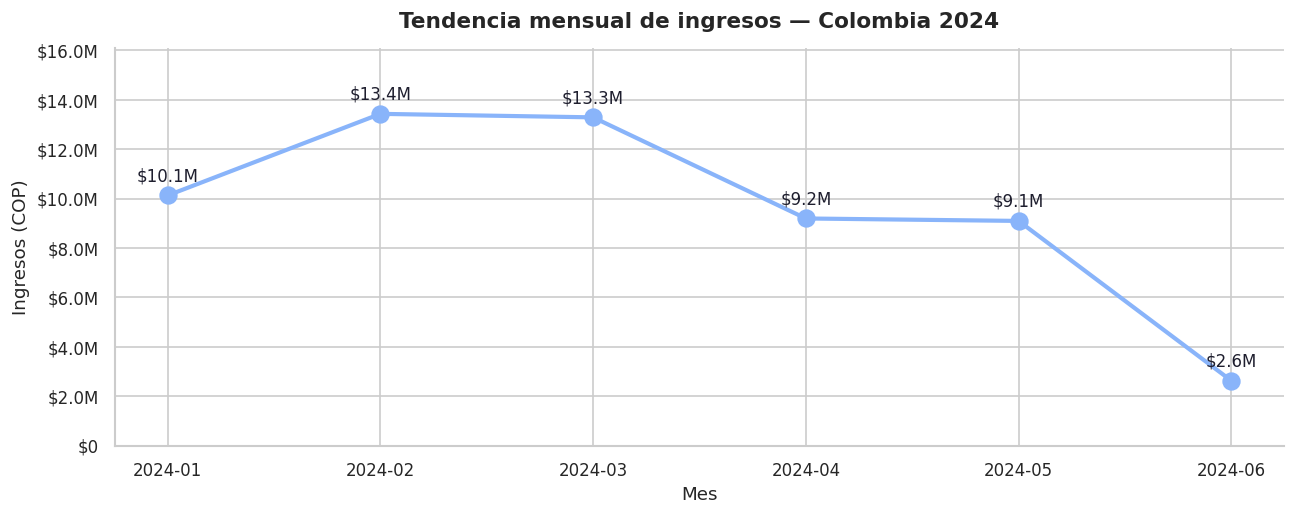

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(tendencia["mes_str"], tendencia["ingreso"],
        marker="o", markersize=10, linewidth=2.5,
        color=PALETA["primario"])

# Etiquetas sobre cada punto
for _, row in tendencia.iterrows():
    ax.text(row["mes_str"], row["ingreso"] + 600_000,
            f"${row['ingreso']/1_000_000:.1f}M",
            ha="center", fontsize=10, color=PALETA["texto"])

ax.set_title("Tendencia mensual de ingresos — Colombia 2024", pad=12)
ax.set_xlabel("Mes")
ax.set_ylabel("Ingresos (COP)")
ax.yaxis.set_major_formatter(formato_cop)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, tendencia["ingreso"].max() * 1.2)

plt.tight_layout()
plt.show()

## Paso 6 — Exportar dataset limpio

El dataset procesado se exporta como `ventas_limpias.csv` para uso posterior.
Encoding `utf-8-sig` preserva tildes y compatibilidad con Excel.

### Conclusiones del análisis exploratorio

A partir de las 46 transacciones limpias del dataset:

1. **Concentración geográfica:** Bogotá representa el 57.3% de los ingresos
   totales, casi 4 veces más que la segunda ciudad. Las otras tres ciudades
   (Medellín, Cali, Barranquilla) se reparten el 42.6% en proporciones
   similares.

2. **Dominio del catálogo electrónico:** Laptop y Celular juntos generan
   el 60.8% del ingreso total. Sumando Tablet y Audífonos, la categoría
   Electrónica representa el 79.2% del negocio.

3. **Estrategia digital:** El canal Online genera el 70.1% de los ingresos
   con un ticket promedio significativamente mayor que Tienda. Cualquier
   plan de crecimiento debería priorizar el canal digital.

4. **Liderazgo individual:** Ana Torres lidera el ranking compuesto con
   score 0.888, combinando el mayor ingreso ($22.0M) con una satisfacción
   alta (4.44/5). María López tiene la mejor satisfacción (4.49) pero
   menor volumen de ventas. Pedro Gómez muestra el peor desempeño
   combinado.

5. **Hallazgo cualitativo:** La correlación entre satisfacción e ingreso
   no es directa. María López y Pedro Gómez ilustran esto: alta
   satisfacción no garantiza alto ingreso, y bajo ingreso puede coexistir
   con baja satisfacción.

6. **Estacionalidad:** Febrero y marzo concentran los mayores ingresos
   (aprox. \$13.3M cada uno), seguidos por enero (\$10.1M). Abril y mayo
   muestran actividad estable (aprox. \$9M). Junio registra el menor
   ingreso del período (\$2.6M) con solo 2 transacciones.

In [ ]:
df.to_csv("ventas_limpias.csv", index=False, encoding="utf-8-sig")
print(f"Archivo exportado : ventas_limpias.csv")
print(f"Dimensiones       : {df.shape[0]} filas x {df.shape[1]} columnas")

Archivo exportado : ventas_limpias.csv
Dimensiones       : 46 filas x 12 columnas


## Paso 7 — Reporte de sesión

Resumen ejecutivo en texto plano con todos los valores calculados.
Sirve como bitácora de la ejecución del notebook y como insumo para
documentación posterior.

In [ ]:
reporte = f"""
{'='*60}
REPORTE DE SESIÓN — Ventas Colombia 2024
{'='*60}

PIPELINE
{'-'*60}
Filas originales         : 49
Duplicados eliminados    : 2
Filas irrecuperables     : 1
Filas limpias            : {len(df)}
Fechas no convertibles   : {df['fecha'].isna().sum()}
NaN en satisfacción      : {df['satisfaccion_cliente'].isna().sum()}

KPIs GENERALES
{'-'*60}
Ingreso total            : ${total:,.0f} COP
Transacciones            : {transacciones}
Ticket promedio          : ${ticket:,.0f} COP
Satisfacción promedio    : {satisfaccion:.2f} / 5.0

INGRESOS POR CIUDAD
{'-'*60}
{ingresos_ciudad.to_string()}

INGRESOS POR CANAL
{'-'*60}
{ingresos_canal.to_string()}

TOP 5 PRODUCTOS
{'-'*60}
{top_productos.to_string()}

RANKING DE VENDEDORES
{'-'*60}
{ranking.to_string()}

{'='*60}
"""

with open("reporte_sesion.txt", "w", encoding="utf-8") as f:
    f.write(reporte)

print(reporte)
print(f"Archivo exportado: reporte_sesion.txt ({len(reporte)} caracteres)")


REPORTE DE SESIÓN — Ventas Colombia 2024

PIPELINE
------------------------------------------------------------
Filas originales         : 49
Duplicados eliminados    : 2
Filas irrecuperables     : 1
Filas limpias            : 46
Fechas no convertibles   : 0
NaN en satisfacción      : 1

KPIs GENERALES
------------------------------------------------------------
Ingreso total            : $57,747,000 COP
Transacciones            : 46
Ticket promedio          : $1,255,370 COP
Satisfacción promedio    : 4.15 / 5.0

INGRESOS POR CIUDAD
------------------------------------------------------------
              ingreso_total  transacciones  ticket_promedio  %_del_total
ciudad                                                                  
Bogotá           33074000.0             15     2.204933e+06         57.3
Medellín          8898000.0             11     8.089091e+05         15.4
Cali              8677000.0             11     7.888182e+05         15.0
Barranquilla      7014000.0       